In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
sales = pd.read_csv('Sales_Fact.csv')
customer = pd.read_csv('Customer_Dimension.csv')
product = pd.read_csv('Product_Dimension.csv')
region = pd.read_csv('Region_Dimension.csv')
inventory = pd.read_csv('Inventory_Dimension.csv')

In [4]:
sales.head()

,TransactionID,CustomerID,ProductID,Region,Quantity,Revenue
0,1,3262,P02804,East,5,320.25
1,2,9453,P04325,West,3,39.06
2,3,4540,P03381,North,2,262.08
3,4,8774,P00636,East,2,299.84
4,5,9492,P00744,East,1,114.06


In [5]:
customer.head()

,CustomerID,CustomerSegment,Team_Affiliation,CustomerLifetimeValue
0,3262,Loyal Fan,Sharks,1802.82
1,9453,Casual Fan,Warriors,810.04
2,4540,Casual Fan,Bulls,2260.49
3,8774,Online Shopper,Lions,4511.13
4,9492,Loyal Fan,Bulls,3866.28


In [6]:
product.head()

,ProductID,Category,UnitPrice
0,P02804,Footwear,64.05
1,P04325,Footwear,13.02
2,P03381,Jerseys,131.04
3,P00636,Accessories,149.92
4,P00744,Footwear,114.06


In [7]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  20000 non-null  int64  
 1   CustomerID     20000 non-null  int64  
 2   ProductID      20000 non-null  object 
 3   Region         20000 non-null  object 
 4   Quantity       20000 non-null  int64  
 5   Revenue        20000 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 937.6+ KB


In [8]:
sales.shape

(20000, 6)

In [9]:
sales.columns

Index(['TransactionID', 'CustomerID', 'ProductID', 'Region', 'Quantity',
       'Revenue'],
      dtype='object')

In [10]:
sales.isnull().sum()

TransactionID    0
CustomerID       0
ProductID        0
Region           0
Quantity         0
Revenue          0
dtype: int64

In [11]:
customer.isnull().sum()

CustomerID               0
CustomerSegment          0
Team_Affiliation         0
CustomerLifetimeValue    0
dtype: int64

In [12]:
product.isnull().sum()

ProductID    0
Category     0
UnitPrice    0
dtype: int64

In [13]:
inventory.isnull().sum()

ProductID             0
InventoryUnits        0
UnitsSold             0
SellThroughRatePct    0
dtype: int64

In [14]:
sales.duplicated().sum()

np.int64(0)

In [15]:
customer.duplicated().sum()

np.int64(0)

In [16]:
sales.describe()

,TransactionID,CustomerID,Quantity,Revenue
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,5535.268000,2.995150,239.405424
std,5773.647028,2598.292304,1.420573,175.798554
min,1.000000,1000.000000,1.000000,10.220000
25%,5000.750000,3284.000000,2.000000,97.707500
50%,10000.500000,5552.000000,3.000000,192.380000
75%,15000.250000,7793.250000,4.000000,352.527500
max,20000.000000,9998.000000,5.000000,749.700000


In [17]:
sales['Revenue'].sum()

np.float64(4788108.48)

In [18]:
sales['Revenue'].mean()

np.float64(239.405424)

In [19]:
sales['Quantity'].sum()

np.int64(59903)

In [22]:
df = sales.merge(customer,on='CustomerID')
df = df.merge(product,on='ProductID')

In [23]:
df.head()

,TransactionID,CustomerID,ProductID,Region,Quantity,Revenue,CustomerSegment,Team_Affiliation,CustomerLifetimeValue,Category,UnitPrice
0,1,3262,P02804,East,5,320.25,Loyal Fan,Sharks,1802.82,Footwear,64.05
1,1,3262,P02804,East,5,320.25,Loyal Fan,Sharks,1802.82,Training Gear,52.53
2,1,3262,P02804,East,5,320.25,Loyal Fan,Sharks,1802.82,Footwear,95.37
3,1,3262,P02804,East,5,320.25,Loyal Fan,Sharks,1802.82,Accessories,113.15
4,1,3262,P02804,East,5,320.25,Loyal Fan,Sharks,1802.82,Fan Merchandise,59.88


In [24]:
category_sales = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

category_sales

Category
Jerseys            22574390.64
Footwear           19395920.01
Accessories        11670099.12
Fan Merchandise    11566803.36
Training Gear      11485744.67
Name: Revenue, dtype: float64

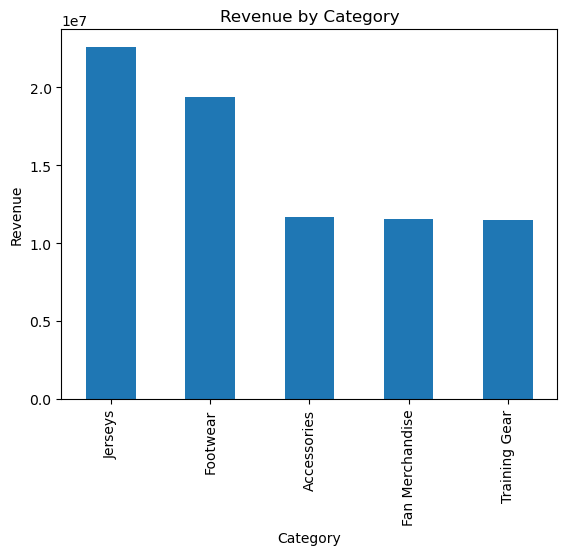

In [25]:
category_sales.plot(kind='bar')

plt.title('Revenue by Category')
plt.ylabel('Revenue')
plt.show()

In [26]:
df['CustomerSegment'].value_counts()

CustomerSegment
Casual Fan              80478
Loyal Fan               80009
Online Shopper          79970
Season Ticket Holder    79132
Name: count, dtype: int64

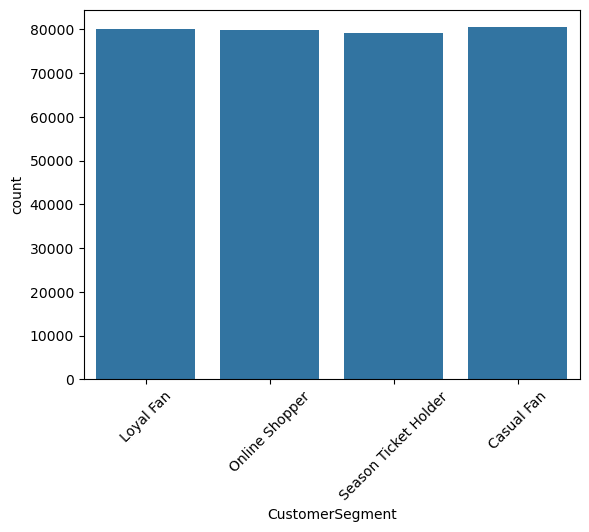

In [27]:
sns.countplot(data=df,x='CustomerSegment')

plt.xticks(rotation=45)
plt.show()

In [28]:
segment_revenue = df.groupby('CustomerSegment')['Revenue'].sum()

segment_revenue

CustomerSegment
Casual Fan              19376416.88
Loyal Fan               19349559.94
Online Shopper          19031235.45
Season Ticket Holder    18935745.53
Name: Revenue, dtype: float64

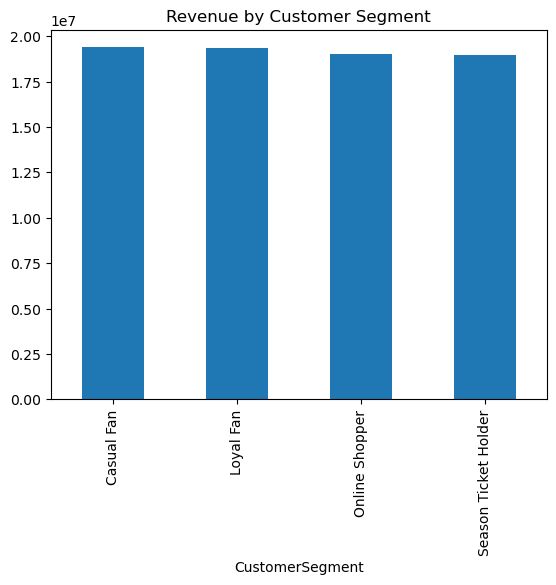

In [29]:
segment_revenue.plot(kind='bar')

plt.title('Revenue by Customer Segment')
plt.show()

In [30]:
team_revenue = df.groupby('Team_Affiliation')['Revenue'].sum()

team_revenue.sort_values(ascending=False).head(10)

Team_Affiliation
Tigers      13232671.75
Eagles      12946257.65
Bulls       12834752.98
Warriors    12747179.06
Sharks      12499857.89
Lions       12432238.47
Name: Revenue, dtype: float64

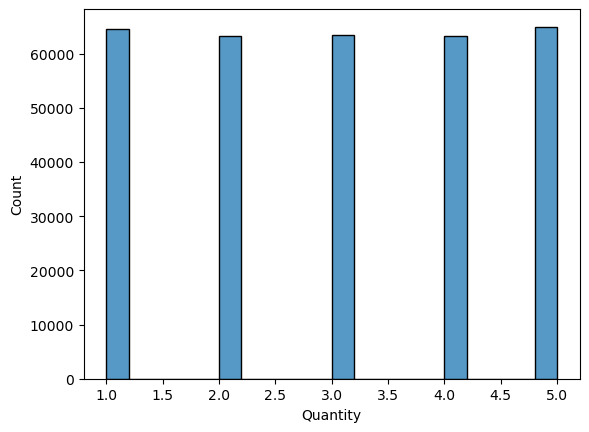

In [31]:
sns.histplot(df['Quantity'],bins=20)

plt.show()

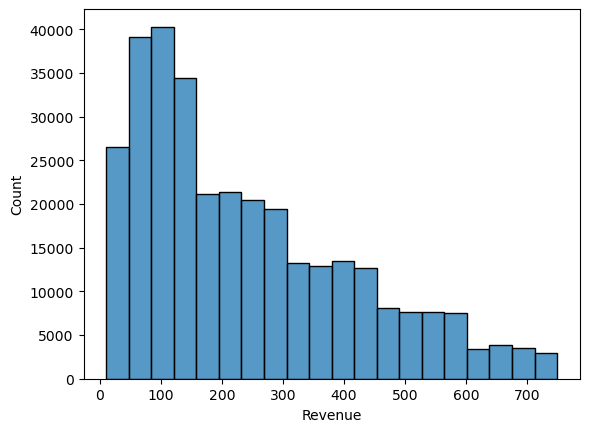

In [32]:
sns.histplot(df['Revenue'],bins=20)

plt.show()

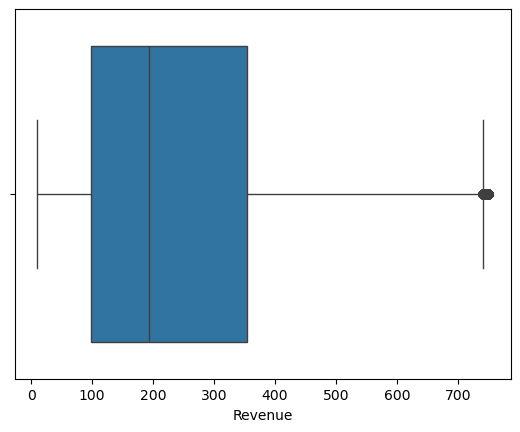

In [33]:
sns.boxplot(x=df['Revenue'])

plt.show()

In [34]:
inventory.describe()

,InventoryUnits,UnitsSold,SellThroughRatePct
count,19983.000000,19983.000000,19983.000000
mean,273.897563,2.854026,1.472842
std,129.594356,1.414129,1.406420
min,50.000000,1.000000,0.200000
25%,161.000000,2.000000,0.600000
50%,275.000000,3.000000,1.040000
75%,384.000000,4.000000,1.770000
max,499.000000,5.000000,10.000000


In [35]:
inventory.sort_values(
    by='InventoryUnits',
    ascending=False
).head(10)

,ProductID,InventoryUnits,UnitsSold,SellThroughRatePct
8264,P04216,499,3,0.6
11502,P03973,499,5,1.0
1295,P03806,499,4,0.8
4523,P03126,499,4,0.8
7223,P04463,499,4,0.8
2705,P02578,499,5,1.0
5778,P04821,499,2,0.4
17887,P00603,499,4,0.8
11566,P00979,499,4,0.8
9879,P04786,499,4,0.8


In [36]:
inventory.sort_values(
    by='SellThroughRatePct'
).head(10)

,ProductID,InventoryUnits,UnitsSold,SellThroughRatePct
8786,P00626,496,1,0.2
147,P01892,495,1,0.2
13740,P01907,492,1,0.2
3354,P03575,496,1,0.2
11550,P00765,491,1,0.2
9077,P00756,489,1,0.2
14581,P03121,498,1,0.2
11461,P02618,488,1,0.2
15562,P00404,492,1,0.2
3545,P01695,495,1,0.2


In [37]:
numeric_cols = df.select_dtypes(include=np.number)

numeric_cols.corr()

,TransactionID,CustomerID,Quantity,Revenue,CustomerLifetimeValue,UnitPrice
TransactionID,1.000000,0.003020,0.001915,0.002581,0.002104,-0.001773
CustomerID,0.003020,1.000000,-0.001818,-0.005489,-0.008141,0.001871
Quantity,0.001915,-0.001818,1.000000,0.648876,-0.002817,-0.000869
Revenue,0.002581,-0.005489,0.648876,1.000000,-0.006340,0.138622
CustomerLifetimeValue,0.002104,-0.008141,-0.002817,-0.006340,1.000000,-0.002493
UnitPrice,-0.001773,0.001871,-0.000869,0.138622,-0.002493,1.000000


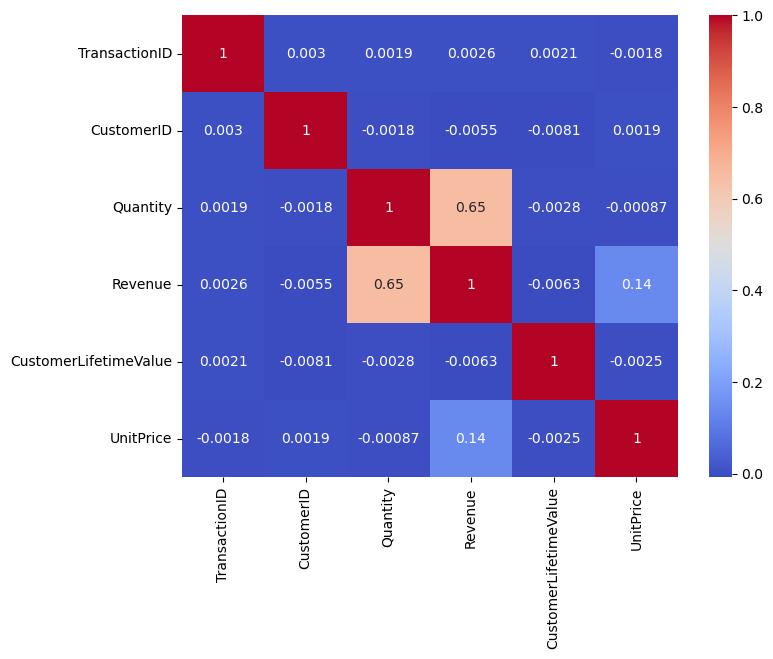

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [39]:
top_products = df.groupby(
    'ProductID'
)['Revenue'].sum().sort_values(
    ascending=False
).head(10)

top_products

ProductID
P02622    167612.16
P04807    155596.87
P03555    134110.57
P04685    132876.54
P02437    116558.72
P00225    114702.80
P01059    114688.92
P02952    112968.02
P03182    105378.00
P00061     95972.00
Name: Revenue, dtype: float64

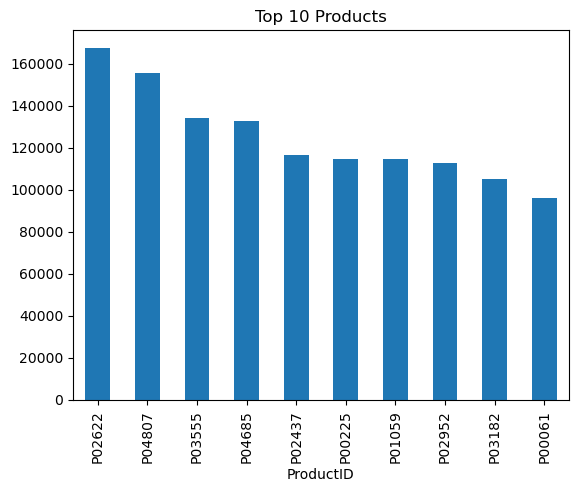

In [40]:
top_products.plot(kind='bar')

plt.title('Top 10 Products')
plt.show()

In [41]:
customer['CustomerLifetimeValue'].describe()

count    20000.000000
mean      2537.509414
std       1410.667028
min        100.010000
25%       1317.667500
50%       2525.270000
75%       3748.285000
max       4999.690000
Name: CustomerLifetimeValue, dtype: float64

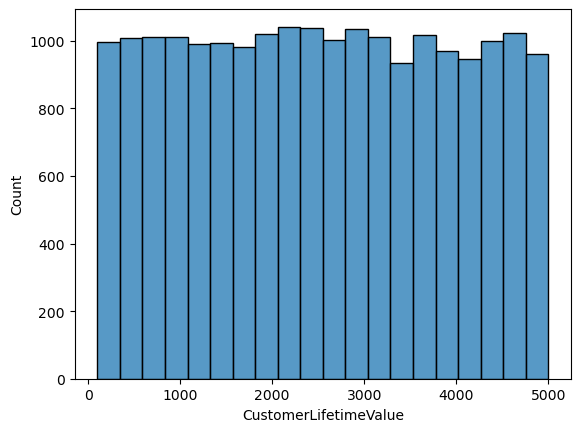

In [42]:
sns.histplot(
    customer['CustomerLifetimeValue'],
    bins=20
)

plt.show()

In [43]:
print("Total Revenue:", sales['Revenue'].sum())

print("Average Revenue:",
      sales['Revenue'].mean())

print("Total Quantity Sold:",
      sales['Quantity'].sum())

print("Unique Customers:",
      customer['CustomerID'].nunique())

print("Unique Products:",
      product['ProductID'].nunique())

Total Revenue: 4788108.48
Average Revenue: 239.405424
Total Quantity Sold: 59903
Unique Customers: 8053
Unique Products: 4899
